<a href="https://colab.research.google.com/github/nicolle-tq/Telecom-X/blob/main/challenge_telecom_x.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Extracción de datos**

En esta etapa se cargan los datos desde el archivo JSON de Telecom X.
Luego los datos se convierten en un DataFrame de Pandas para poder analizar.

In [2]:
import pandas as pd
df = pd.read_json("/TelecomX_Data.json")

In [3]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


# **Transformación**

## **Conociendo el conjunto de datos**

En esta etapa se revisa la estructura del dataset para entender qué información contiene.

Se exploran las columnas, los tipos de datos y algunas filas para comprender mejor las variables disponibles.

In [5]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [6]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [8]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## **Manejo de inconsistencias**

En esta etapa se corrigen algunos problemas encontrados en los datos.

### **Normalización de datos**

Al revisar el dataset se observó que algunas columnas contienen datos en formato de diccionario


Para poder analizarlos correctamente, se utiliza pd.json_normalize


In [9]:
df = pd.json_normalize(df.to_dict(orient="records"))

In [10]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

**Esto es importante para asegurar que los datos estén limpios antes de realizar
el análisis.**

In [11]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [12]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [13]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [14]:
df = df.dropna()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

## **Creación de la columna Cuentas_Diarias**

Se crea una nueva variable que representa el gasto promedio diario
del cliente a partir del cargo mensual.

In [16]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

In [17]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## **Estandarización y transformación de datos**

En esta etapa se busca hacer que los datos sean más consistentes
y fáciles de analizar.

In [18]:
df["Churn_binario"] = df["Churn"].map({"Yes": 1, "No": 0})

df[["Churn","Churn_binario"]].head()

,Churn,Churn_binario
0,No,0.0
1,No,0.0
2,Yes,1.0
3,Yes,1.0
4,Yes,1.0


In [19]:
df.replace({
    "No internet service": "No",
    "No phone service": "No"
}, inplace=True)

In [20]:
df.rename(columns={
    "customerID": "Cliente_ID",
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "Adulto_Mayor",
    "account.Contract": "Tipo_Contrato",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total"
}, inplace=True)

df.columns

Index(['Cliente_ID', 'Churn', 'Genero', 'Adulto_Mayor', 'customer.Partner',
       'customer.Dependents', 'customer.tenure', 'phone.PhoneService',
       'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato',
       'account.PaperlessBilling', 'account.PaymentMethod', 'Cargo_Mensual',
       'Cargo_Total', 'Cuentas_Diarias', 'Churn_binario'],
      dtype='object')

In [21]:
df["Adulto_Mayor"] = df["Adulto_Mayor"].replace({1:"Yes",0:"No"})

In [22]:
df.head()

,Cliente_ID,Churn,Genero,Adulto_Mayor,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,0.0
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0.0
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1.0
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1.0
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cliente_ID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   Genero                     7256 non-null   object 
 3   Adulto_Mayor               7256 non-null   object 
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

# **Carga y análisis de datos (Load & Analysis)**

En esta etapa se cargan los datos del archivo JSON y se realiza
una exploración inicial del dataset.

El objetivo es comprender la estructura de los datos,
identificar las variables disponibles y detectar posibles
inconsistencias antes de iniciar la limpieza y transformación.

## **Análisis Descriptivo**

En esta etapa se calculan métricas estadísticas para comprender
mejor el comportamiento de los clientes.

Se analizan variables numéricas como:

- Cargo_Mensual
- Cargo_Total
- Cuentas_Diarias

Estas métricas incluyen media, mediana, desviación estándar
y percentiles.

In [24]:
df.describe()

,customer.tenure,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Churn_binario
count,7256.000000,7256.000000,7256.000000,7256.000000,7032.000000
mean,32.395535,64.755423,2280.634213,2.158514,0.265785
std,24.558067,30.125739,2268.632997,1.004191,0.441782
min,1.000000,18.250000,18.800000,0.608333,0.000000
25%,9.000000,35.450000,400.225000,1.181667,0.000000
50%,29.000000,70.300000,1391.000000,2.343333,0.000000
75%,55.000000,89.900000,3785.300000,2.996667,1.000000
max,72.000000,118.750000,8684.800000,3.958333,1.000000


In [25]:
df["Cargo_Mensual"].describe()

,Cargo_Mensual
count,7256.000000
mean,64.755423
std,30.125739
min,18.250000
25%,35.450000
50%,70.300000
75%,89.900000
max,118.750000


In [26]:
df["Cargo_Total"].describe()

,Cargo_Total
count,7256.000000
mean,2280.634213
std,2268.632997
min,18.800000
25%,400.225000
50%,1391.000000
75%,3785.300000
max,8684.800000


In [27]:
df["Cuentas_Diarias"].describe()

,Cuentas_Diarias
count,7256.000000
mean,2.158514
std,1.004191
min,0.608333
25%,1.181667
50%,2.343333
75%,2.996667
max,3.958333


In [28]:
df.groupby("Churn")[["Cargo_Mensual","Cargo_Total"]].mean()

,Cargo_Mensual,Cargo_Total
Churn,,
,63.412277,2196.933705
No,61.307408,2555.344141
Yes,74.441332,1531.796094


## **Gráfico de evasión de clientes**

En esta etapa se analiza la distribución de clientes que cancelaron
el servicio frente a los que permanecieron en la empresa.

In [29]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869
,224


In [30]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.154906
Yes,25.757993
,3.087100


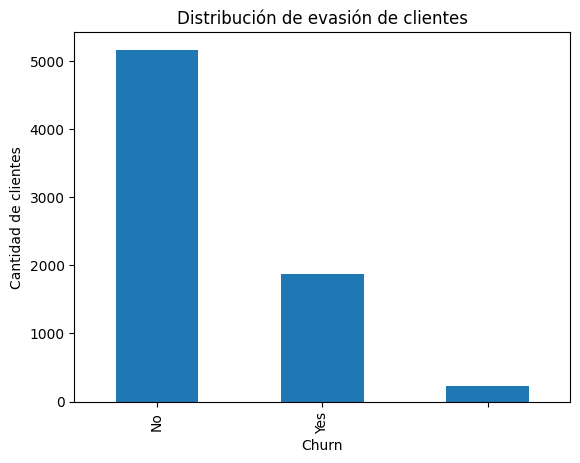

In [31]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de evasión de clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

## **Evasión según variables categóricas**

En esta sección se analiza cómo se distribuye la evasión
según variables como:

- género
- tipo de contrato
- método de pago

In [32]:
df.groupby("Genero")["Churn"].value_counts()

Genero  Churn
Female  No       2544
        Yes       939
                  104
Male    No       2619
        Yes       930
                  120
Name: count, dtype: int64

In [33]:
df.groupby("Tipo_Contrato")["Churn"].value_counts()

Tipo_Contrato   Churn
Month-to-month  No       2220
                Yes      1655
                          130
One year        No       1306
                Yes       166
                           46
Two year        No       1637
                           48
                Yes        48
Name: count, dtype: int64

## **Evasión según variables numéricas**

Aquí analizamos cómo variables numéricas como
los cargos mensuales y totales se relacionan
con la evasión de clientes.

In [34]:
df.groupby("Churn")["Cargo_Mensual"].mean()

,Cargo_Mensual
Churn,
,63.412277
No,61.307408
Yes,74.441332


In [35]:
df.groupby("Churn")["Cargo_Total"].mean()

,Cargo_Total
Churn,
,2196.933705
No,2555.344141
Yes,1531.796094


Informe Final


                        Introducción

Este análisis tiene como objetivo explorar los datos de clientes de Telecom X para entender los factores relacionados con la evasión de clientes (Churn).

Se trabajó con un conjunto de datos en formato JSON que contiene información sobre características de los clientes, tipo de contrato, cargos mensuales y totales, entre otras variables.

Durante el proceso se realizaron tareas de limpieza, transformación y exploración de los datos para poder analizarlos de manera adecuada.

                   Hallazgos del análisis

A partir del análisis exploratorio se pudieron observar algunos patrones relacionados con la evasión de clientes.

Existe una proporción significativa de clientes que cancelan el servicio.

Los clientes con cargos mensuales más altos parecen tener mayor probabilidad de evasión.

El tipo de contrato también parece influir en la permanencia de los clientes.

Algunas variables categóricas como género o servicios contratados muestran diferencias en la distribución del churn.

Estos resultados permiten identificar posibles factores que influyen en la cancelación del servicio.

                   Recomendaciones

A partir del análisis realizado, se pueden considerar algunas estrategias para reducir la evasión de clientes:

Revisar los planes con cargos mensuales altos, ya que podrían estar asociados a mayor churn.

Incentivar contratos de mayor duración, lo que podría ayudar a mejorar la retención de clientes.

Analizar más a fondo los perfiles de clientes que cancelan el servicio para entender mejor sus necesidades.

Estos resultados pueden servir como punto de partida para futuros análisis más avanzados.